In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import json
import pandas as pd

In [2]:
import matplotlib
font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 20}

matplotlib.rc('font', **font)

In [3]:
with open('phising/accuracy_dict_5.pkl', 'rb') as file:
    phising_5 = pickle.load(file)
with open('phising/accuracy_dict_10.pkl', 'rb') as file:
    phising_10 = pickle.load(file)
with open('phising/accuracy_dict_15.pkl', 'rb') as file:
    phising_15 = pickle.load(file)

with open('cinic_noise_results/di_accuracy_dict_ci.json', 'rb') as file:
    cinic_di_12 = json.load(file)
with open('cinic_noise_results/di_accuracy_dict_ci_3.json', 'rb') as file:
    cinic_di_8 = json.load(file)
with open('cinic_noise_results/di_accuracy_dict_ci_2.json', 'rb') as file:
    cinic_di_16 = json.load(file)

with open('cinic_noise_results/fl_accuracy_dict_ci.json', 'rb') as file:
    cinic_fl_12 = json.load(file)
with open('cinic_noise_results/fl_accuracy_dict_ci_3.json', 'rb') as file:
    cinic_fl_8 = json.load(file)
with open('cinic_noise_results/fl_accuracy_dict_ci_2.json', 'rb') as file:
    cinic_fl_16 = json.load(file)

with open('dmoz_exps/accuracy_dict_3.pkl', 'rb') as file:
    dmoz_3 = pickle.load(file)
with open('dmoz_exps/accuracy_dict_5.pkl', 'rb') as file:
    dmoz_5 = pickle.load(file)
with open('dmoz_exps/accuracy_dict_7.pkl', 'rb') as file:
    dmoz_7 = pickle.load(file)
with open('dmoz_exps/accuracy_dict_10.pkl', 'rb') as file:
    dmoz_10 = pickle.load(file)

### Phising Borda

In [4]:
phising_borda = {k: [phising_5[k]['borda'], phising_10[k]['borda'], phising_15[k]['borda']] for k in phising_5.keys()}

In [5]:
key_mapping = {
    "loo": "LOO weighted",
    "unweighted": "Unweighted",
    "accuracy": "Acc weighted",
    "crh": "CRH weighted",
    "entropy": "Inv. Entropy weighted",
    "shapley": "Shap weighted",
    "regression": "Regression"
}

# Create a new dictionary with the desired order
phising_borda = {key_mapping[key]: phising_borda[key] for key in key_mapping}

In [6]:
markers = [".-",",-","o-","v-","^-","<-",">-","1-","2-","3-","4-","s-","p","P","*","h","H","+","x","X","D","d","|","_"]

In [7]:
# Store medians for different number of teachers for all methods
phising_borda_meds = []
for method in phising_borda.keys():
    # if "LOO" not in method:
    phising_borda_meds.append(np.median(phising_borda[method], axis=0))
phising_borda_meds = np.array(phising_borda_meds)

phising_borda_ranks = []

for i in range(phising_borda_meds.shape[1]):
    phising_borda_ranks.append(len(phising_borda_meds[:,i]) - phising_borda_meds[:,i].argsort().argsort())

boxes = [(i,j) for i in range(3) for j in range(7)]
phising_borda_ranks_dict = {(i,j):phising_borda_ranks[i][j] for i in range(3) for j in range(7)}

In [8]:
phising_borda.keys()

dict_keys(['LOO weighted', 'Unweighted', 'Acc weighted', 'CRH weighted', 'Inv. Entropy weighted', 'Shap weighted', 'Regression'])

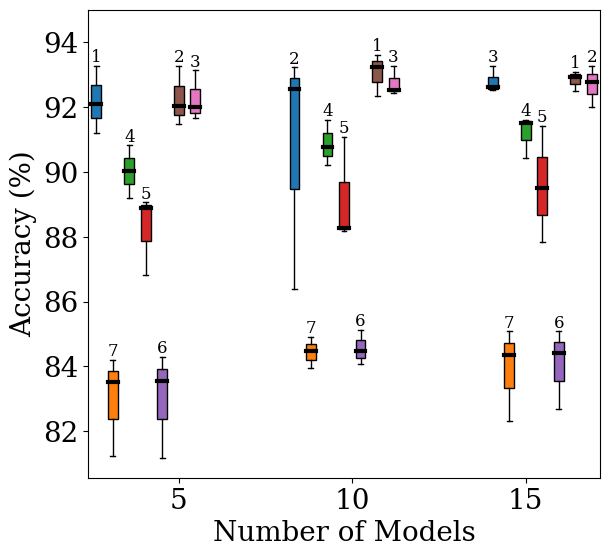

In [9]:
plt.figure(figsize=(6.5, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
artists = []

teachers = [5,10,15]
num_teachers = len(teachers)
techniques = list(phising_borda.keys())
num_techniques = len(techniques)

# Dictionary to store median values for each box
medians_dict = {}
rank_pos_dict = {}
for teacher_index in range(num_teachers):
    x_positions = np.arange(num_techniques) + 1.5*teacher_index * (num_techniques + 1)
    for technique_index, technique in enumerate(techniques):
        arr = np.array(phising_borda[technique])
        bp = plt.boxplot(arr[:, teacher_index], medianprops=dict(color="black", linewidth=3), positions=[x_positions[technique_index]], widths=0.6, patch_artist=True, showfliers=False)
        [box.set_facecolor(colors[technique_index]) for box in bp['boxes']]
        artists.append(bp['boxes'][0])

        # Calculate median value for each box and store it in the dictionary
        median_val = bp['whiskers'][1].get_ydata()[0] #np.median(100 * arr[:, teacher_index])
        medians_dict[(teacher_index, technique_index)] = median_val
        rank_pos_dict[(teacher_index, technique_index)] = bp['whiskers'][1].get_ydata()[1]

# Annotate boxes with ranks
for teacher_index in range(num_teachers):
    for technique_index, technique in enumerate(techniques):
        box = (teacher_index, technique_index)
        rank = phising_borda_ranks_dict[box]
        median_val = medians_dict[box]
        rank_pos = rank_pos_dict[box]
        plt.text(1.5*teacher_index * (num_techniques + 1) + technique_index, rank_pos, rank, ha='center', va='bottom', size = 12)

plt.xticks(np.arange(num_teachers) * (num_techniques+3.5) + num_techniques-2, [f'{teachers[i]}' for i in range(num_teachers)])
# plt.legend(artists, techniques, loc='lower left')
plt.ylabel('Accuracy (%)')
plt.xlabel('Number of Models')
plt.tight_layout()
plt.ylim(top = 95)
plt.savefig('phising_borda.pdf')
plt.show()

### Phising Plurality

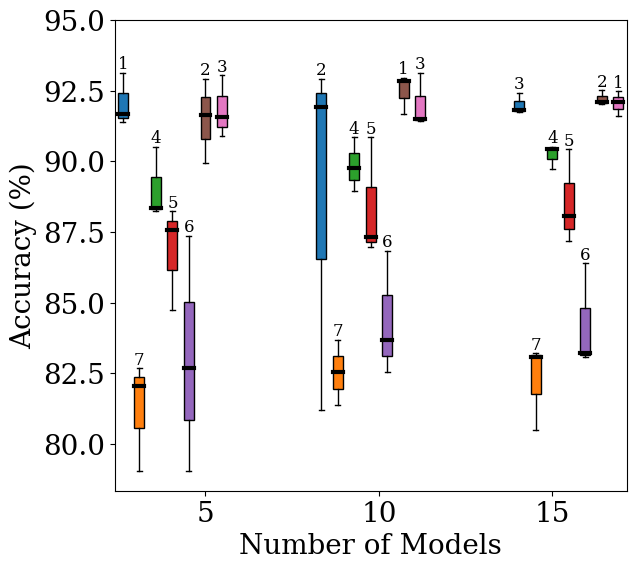

In [10]:
phising_plurality = {k: [phising_5[k]['plurality'], phising_10[k]['plurality'], phising_15[k]['plurality']] for k in phising_5.keys()}
key_mapping = {
    "loo": "LOO weighted",
    "unweighted": "Unweighted",
    "accuracy": "Acc weighted",
    "crh": "CRH weighted",
    "entropy": "Inv. Entropy weighted",
    "shapley": "Shap weighted",
    "regression": "Regression"
}

# Create a new dictionary with the desired order
phising_plurality = {key_mapping[key]: phising_plurality[key] for key in key_mapping}
markers = [".-",",-","o-","v-","^-","<-",">-","1-","2-","3-","4-","s-","p","P","*","h","H","+","x","X","D","d","|","_"]
# Store medians for different number of teachers for all methods
phising_plurality_meds = []
for method in phising_plurality.keys():
    # if "LOO" not in method:
    phising_plurality_meds.append(np.median(phising_plurality[method], axis=0))
phising_plurality_meds = np.array(phising_plurality_meds)

phising_plurality_ranks = []

for i in range(phising_plurality_meds.shape[1]):
    phising_plurality_ranks.append(len(phising_plurality_meds[:,i]) - phising_plurality_meds[:,i].argsort().argsort())

boxes = [(i,j) for i in range(3) for j in range(7)]
phising_plurality_ranks_dict = {(i,j):phising_plurality_ranks[i][j] for i in range(3) for j in range(7)}
phising_plurality.keys()

plt.figure(figsize=(6.5, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
artists = []

teachers = [5,10,15]
num_teachers = len(teachers)
techniques = list(phising_plurality.keys())
num_techniques = len(techniques)

# Dictionary to store median values for each box
medians_dict = {}
rank_pos_dict = {}
for teacher_index in range(num_teachers):
    x_positions = np.arange(num_techniques) + 1.5*teacher_index * (num_techniques + 1)
    for technique_index, technique in enumerate(techniques):
        arr = np.array(phising_plurality[technique])
        bp = plt.boxplot(arr[:, teacher_index], medianprops=dict(color="black", linewidth=3), positions=[x_positions[technique_index]], widths=0.6, patch_artist=True, showfliers=False)
        [box.set_facecolor(colors[technique_index]) for box in bp['boxes']]
        artists.append(bp['boxes'][0])

        # Calculate median value for each box and store it in the dictionary
        median_val = bp['whiskers'][1].get_ydata()[0] #np.median(100 * arr[:, teacher_index])
        medians_dict[(teacher_index, technique_index)] = median_val
        rank_pos_dict[(teacher_index, technique_index)] = bp['whiskers'][1].get_ydata()[1]

# Annotate boxes with ranks
for teacher_index in range(num_teachers):
    for technique_index, technique in enumerate(techniques):
        box = (teacher_index, technique_index)
        rank = phising_plurality_ranks_dict[box]
        median_val = medians_dict[box]
        rank_pos = rank_pos_dict[box]
        plt.text(1.5*teacher_index * (num_techniques + 1) + technique_index, rank_pos, rank, ha='center', va='bottom', size = 12)

plt.xticks(np.arange(num_teachers) * (num_techniques+3.5) + num_techniques-2, [f'{teachers[i]}' for i in range(num_teachers)])
# plt.legend(artists, techniques, loc='lower left')
plt.ylabel('Accuracy (%)')
plt.xlabel('Number of Models')
plt.tight_layout()
plt.ylim(top = 95)
plt.savefig('phising_plurality.pdf')
plt.show()

### DMOZ

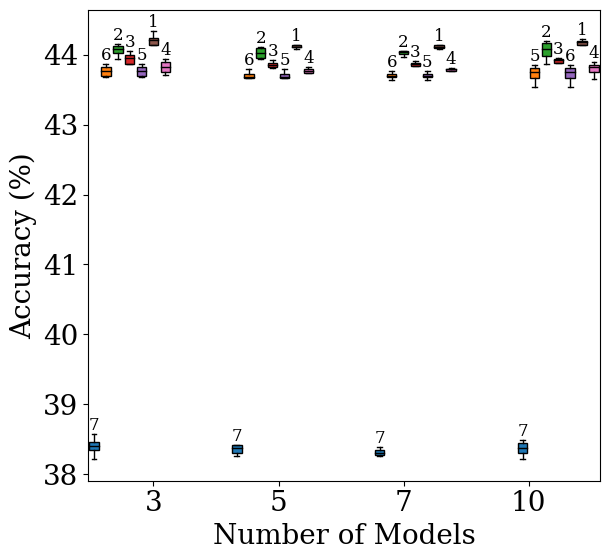

In [53]:
dmoz_borda = {k: [dmoz_3[k]['borda'], dmoz_5[k]['borda'], dmoz_7[k]['borda'], dmoz_10[k]['borda']] for k in dmoz_3.keys()}
key_mapping = {
    "loo": "LOO weighted",
    "unweighted": "Unweighted",
    "accuracy": "Acc weighted",
    "crh": "CRH weighted",
    "entropy": "Inv. Entropy weighted",
    "shapley": "Shap weighted",
    "regression": "Regression"
}

# Create a new dictionary with the desired order
dmoz_borda = {key_mapping[key]: dmoz_borda[key] for key in key_mapping}
markers = [".-",",-","o-","v-","^-","<-",">-","1-","2-","3-","4-","s-","p","P","*","h","H","+","x","X","D","d","|","_"]
# Store medians for different number of teachers for all methods
dmoz_borda_meds = []
for method in dmoz_borda.keys():
    # if "LOO" not in method:
    dmoz_borda_meds.append(np.median(dmoz_borda[method], axis=0))
dmoz_borda_meds = np.array(dmoz_borda_meds)

dmoz_borda_ranks = []

for i in range(dmoz_borda_meds.shape[1]):
    dmoz_borda_ranks.append(len(dmoz_borda_meds[:,i]) - dmoz_borda_meds[:,i].argsort().argsort())

boxes = [(i,j) for i in range(3) for j in range(7)]
dmoz_borda_ranks_dict = {(i,j):dmoz_borda_ranks[i][j] for i in range(4) for j in range(7)}
dmoz_borda.keys()

plt.figure(figsize=(6.5, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
artists = []

teachers = [3,5,7,10]
num_teachers = len(teachers)
techniques = list(dmoz_borda.keys())
num_techniques = len(techniques)

# Dictionary to store median values for each box
medians_dict = {}
rank_pos_dict = {}
for teacher_index in range(num_teachers):
    x_positions = np.arange(num_techniques) + 1.5*teacher_index * (num_techniques + 1)
    for technique_index, technique in enumerate(techniques):
        arr = np.array(dmoz_borda[technique])
        bp = plt.boxplot(arr[:, teacher_index], medianprops=dict(color='black', linewidth=1), positions=[x_positions[technique_index]], widths=0.8, patch_artist=True, showfliers=False)
        [box.set_facecolor(colors[technique_index]) for box in bp['boxes']]
        artists.append(bp['boxes'][0])

        # Calculate median value for each box and store it in the dictionary
        median_val = bp['whiskers'][1].get_ydata()[0] #np.median(100 * arr[:, teacher_index])
        medians_dict[(teacher_index, technique_index)] = median_val
        rank_pos_dict[(teacher_index, technique_index)] = bp['whiskers'][1].get_ydata()[1]

# Annotate boxes with ranks
for teacher_index in range(num_teachers):
    for technique_index, technique in enumerate(techniques):
        box = (teacher_index, technique_index)
        rank = dmoz_borda_ranks_dict[box]
        median_val = medians_dict[box]
        rank_pos = rank_pos_dict[box]
        plt.text(1.5*teacher_index * (num_techniques + 1) + technique_index, rank_pos, rank, ha='center', va='bottom', size = 12)

plt.xticks(np.arange(num_teachers) * (num_techniques+3.5) + num_techniques-2, [f'{teachers[i]}' for i in range(num_teachers)])
# plt.legend(artists, techniques, loc='lower left')
plt.ylabel('Accuracy (%)')
plt.xlabel('Number of Models')
plt.tight_layout()
# plt.ylim(top = 79)
plt.savefig('dmoz_borda.pdf')
plt.show()

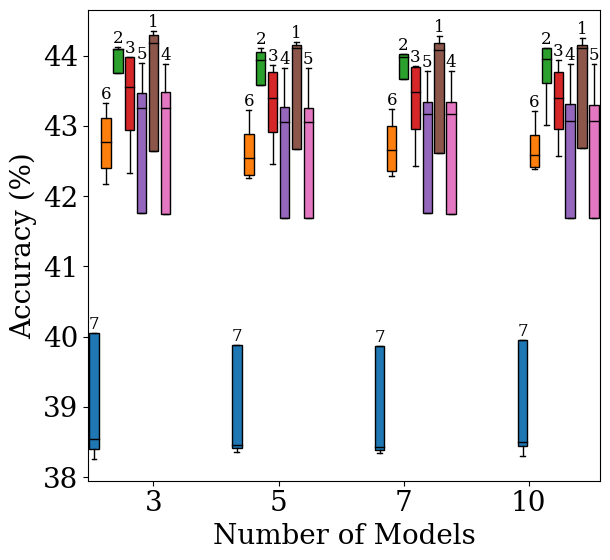

In [54]:
dmoz_plurality = {k: [dmoz_3[k]['plurality'], dmoz_5[k]['plurality'], dmoz_7[k]['plurality'], dmoz_10[k]['plurality']] for k in dmoz_3.keys()}
key_mapping = {
    "loo": "LOO weighted",
    "unweighted": "Unweighted",
    "accuracy": "Acc weighted",
    "crh": "CRH weighted",
    "entropy": "Inv. Entropy weighted",
    "shapley": "Shap weighted",
    "regression": "Regression"
}

# Create a new dictionary with the desired order
dmoz_plurality = {key_mapping[key]: dmoz_plurality[key] for key in key_mapping}
markers = [".-",",-","o-","v-","^-","<-",">-","1-","2-","3-","4-","s-","p","P","*","h","H","+","x","X","D","d","|","_"]
# Store medians for different number of teachers for all methods
dmoz_plurality_meds = []
for method in dmoz_plurality.keys():
    # if "LOO" not in method:
    dmoz_plurality_meds.append(np.median(dmoz_plurality[method], axis=0))
dmoz_plurality_meds = np.array(dmoz_plurality_meds)

dmoz_plurality_ranks = []

for i in range(dmoz_plurality_meds.shape[1]):
    dmoz_plurality_ranks.append(len(dmoz_plurality_meds[:,i]) - dmoz_plurality_meds[:,i].argsort().argsort())

boxes = [(i,j) for i in range(3) for j in range(7)]
dmoz_plurality_ranks_dict = {(i,j):dmoz_plurality_ranks[i][j] for i in range(4) for j in range(7)}
dmoz_plurality.keys()

plt.figure(figsize=(6.5, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
artists = []

teachers = [3,5,7,10]
num_teachers = len(teachers)
techniques = list(dmoz_plurality.keys())
num_techniques = len(techniques)

# Dictionary to store median values for each box
medians_dict = {}
rank_pos_dict = {}
for teacher_index in range(num_teachers):
    x_positions = np.arange(num_techniques) + 1.5*teacher_index * (num_techniques + 1)
    for technique_index, technique in enumerate(techniques):
        arr = np.array(dmoz_plurality[technique])
        bp = plt.boxplot(arr[:, teacher_index], medianprops=dict(color='black', linewidth=1), positions=[x_positions[technique_index]], widths=0.8, patch_artist=True, showfliers=False)
        [box.set_facecolor(colors[technique_index]) for box in bp['boxes']]
        artists.append(bp['boxes'][0])

        # Calculate median value for each box and store it in the dictionary
        median_val = bp['whiskers'][1].get_ydata()[0] #np.median(100 * arr[:, teacher_index])
        medians_dict[(teacher_index, technique_index)] = median_val
        rank_pos_dict[(teacher_index, technique_index)] = bp['whiskers'][1].get_ydata()[1]

# Annotate boxes with ranks
for teacher_index in range(num_teachers):
    for technique_index, technique in enumerate(techniques):
        box = (teacher_index, technique_index)
        rank = dmoz_plurality_ranks_dict[box]
        median_val = medians_dict[box]
        rank_pos = rank_pos_dict[box]
        plt.text(1.5*teacher_index * (num_techniques + 1) + technique_index, rank_pos, rank, ha='center', va='bottom', size = 12)

plt.xticks(np.arange(num_teachers) * (num_techniques+3.5) + num_techniques-2, [f'{teachers[i]}' for i in range(num_teachers)])
# plt.legend(artists, techniques, loc='lower left')
plt.ylabel('Accuracy (%)')
plt.xlabel('Number of Models')
plt.tight_layout()
# plt.ylim(top = 79)
plt.savefig('dmoz_plurality.pdf')
plt.show()

### CINIC DI borda

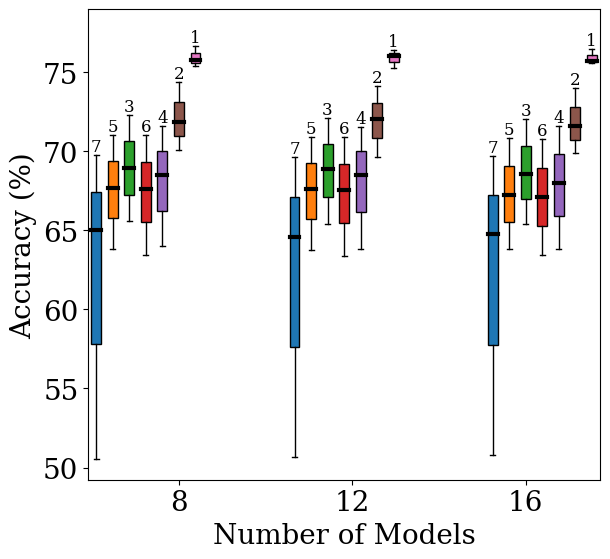

In [13]:
cinic_di_borda = {k: [cinic_di_8[k]['borda'], cinic_di_12[k]['borda'], cinic_di_16[k]['borda']] for k in cinic_di_8.keys()}
key_mapping = {
    "loo": "LOO weighted",
    "unweighted": "Unweighted",
    "accuracy": "Acc weighted",
    "crh": "CRH weighted",
    "entropy": "Inv. Entropy weighted",
    "shapley": "Shap weighted",
    "regression": "Regression"
}

# Create a new dictionary with the desired order
cinic_di_borda = {key_mapping[key]: cinic_di_borda[key] for key in key_mapping}
markers = [".-",",-","o-","v-","^-","<-",">-","1-","2-","3-","4-","s-","p","P","*","h","H","+","x","X","D","d","|","_"]
# Store medians for different number of teachers for all methods
cinic_di_borda_meds = []
for method in cinic_di_borda.keys():
    # if "LOO" not in method:
    cinic_di_borda_meds.append(np.median(cinic_di_borda[method], axis=0))
cinic_di_borda_meds = np.array(cinic_di_borda_meds)

cinic_di_borda_ranks = []

for i in range(cinic_di_borda_meds.shape[1]):
    cinic_di_borda_ranks.append(len(cinic_di_borda_meds[:,i]) - cinic_di_borda_meds[:,i].argsort().argsort())

boxes = [(i,j) for i in range(3) for j in range(7)]
cinic_di_borda_ranks_dict = {(i,j):cinic_di_borda_ranks[i][j] for i in range(3) for j in range(7)}
cinic_di_borda.keys()

plt.figure(figsize=(6.5, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
artists = []

teachers = [8,12,16]
num_teachers = len(teachers)
techniques = list(cinic_di_borda.keys())
num_techniques = len(techniques)

# Dictionary to store median values for each box
medians_dict = {}
rank_pos_dict = {}
for teacher_index in range(num_teachers):
    x_positions = np.arange(num_techniques) + 1.5*teacher_index * (num_techniques + 1)
    for technique_index, technique in enumerate(techniques):
        arr = np.array(cinic_di_borda[technique])
        bp = plt.boxplot(arr[:, teacher_index], medianprops=dict(color="black", linewidth=3), positions=[x_positions[technique_index]], widths=0.6, patch_artist=True, showfliers=False)
        [box.set_facecolor(colors[technique_index]) for box in bp['boxes']]
        artists.append(bp['boxes'][0])

        # Calculate median value for each box and store it in the dictionary
        median_val = bp['whiskers'][1].get_ydata()[0] #np.median(100 * arr[:, teacher_index])
        medians_dict[(teacher_index, technique_index)] = median_val
        rank_pos_dict[(teacher_index, technique_index)] = bp['whiskers'][1].get_ydata()[1]

# Annotate boxes with ranks
for teacher_index in range(num_teachers):
    for technique_index, technique in enumerate(techniques):
        box = (teacher_index, technique_index)
        rank = cinic_di_borda_ranks_dict[box]
        median_val = medians_dict[box]
        rank_pos = rank_pos_dict[box]
        plt.text(1.5*teacher_index * (num_techniques + 1) + technique_index, rank_pos, rank, ha='center', va='bottom', size = 12)

plt.xticks(np.arange(num_teachers) * (num_techniques+3.5) + num_techniques-2, [f'{teachers[i]}' for i in range(num_teachers)])
# plt.legend(artists, techniques, loc='lower left')
plt.ylabel('Accuracy (%)')
plt.xlabel('Number of Models')
plt.tight_layout()
plt.ylim(top = 79)
plt.savefig('cinic_di_borda.pdf')
plt.show()

### CINIC DI plurality

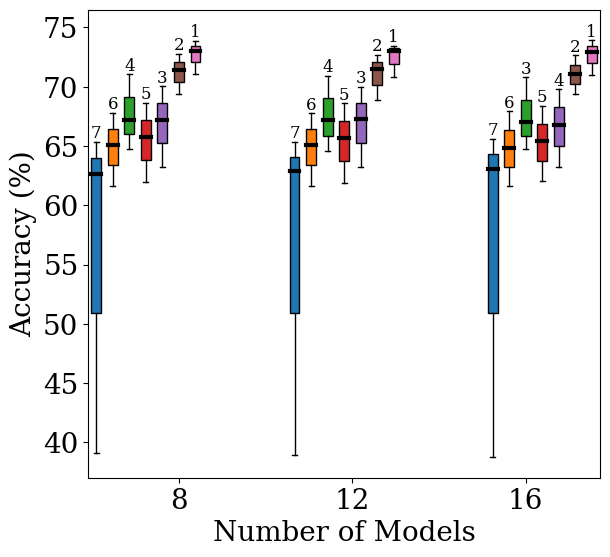

In [14]:
cinic_di_plurality = {k: [cinic_di_8[k]['plurality'], cinic_di_12[k]['plurality'], cinic_di_16[k]['plurality']] for k in cinic_di_8.keys()}
key_mapping = {
    "loo": "LOO weighted",
    "unweighted": "Unweighted",
    "accuracy": "Acc weighted",
    "crh": "CRH weighted",
    "entropy": "Inv. Entropy weighted",
    "shapley": "Shap weighted",
    "regression": "Regression"
}

# Create a new dictionary with the desired order
cinic_di_plurality = {key_mapping[key]: cinic_di_plurality[key] for key in key_mapping}
markers = [".-",",-","o-","v-","^-","<-",">-","1-","2-","3-","4-","s-","p","P","*","h","H","+","x","X","D","d","|","_"]
# Store medians for different number of teachers for all methods
cinic_di_plurality_meds = []
for method in cinic_di_plurality.keys():
    # if "LOO" not in method:
    cinic_di_plurality_meds.append(np.median(cinic_di_plurality[method], axis=0))
cinic_di_plurality_meds = np.array(cinic_di_plurality_meds)

cinic_di_plurality_ranks = []

for i in range(cinic_di_plurality_meds.shape[1]):
    cinic_di_plurality_ranks.append(len(cinic_di_plurality_meds[:,i]) - cinic_di_plurality_meds[:,i].argsort().argsort())

boxes = [(i,j) for i in range(3) for j in range(7)]
cinic_di_plurality_ranks_dict = {(i,j):cinic_di_plurality_ranks[i][j] for i in range(3) for j in range(7)}
cinic_di_plurality.keys()

plt.figure(figsize=(6.5, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
artists = []

teachers = [8,12,16]
num_teachers = len(teachers)
techniques = list(cinic_di_plurality.keys())
num_techniques = len(techniques)

# Dictionary to store median values for each box
medians_dict = {}
rank_pos_dict = {}
for teacher_index in range(num_teachers):
    x_positions = np.arange(num_techniques) + 1.5*teacher_index * (num_techniques + 1)
    for technique_index, technique in enumerate(techniques):
        arr = np.array(cinic_di_plurality[technique])
        bp = plt.boxplot(arr[:, teacher_index], medianprops=dict(color="black", linewidth=3), positions=[x_positions[technique_index]], widths=0.6, patch_artist=True, showfliers=False)
        [box.set_facecolor(colors[technique_index]) for box in bp['boxes']]
        artists.append(bp['boxes'][0])

        # Calculate median value for each box and store it in the dictionary
        median_val = bp['whiskers'][1].get_ydata()[0] #np.median(100 * arr[:, teacher_index])
        medians_dict[(teacher_index, technique_index)] = median_val
        rank_pos_dict[(teacher_index, technique_index)] = bp['whiskers'][1].get_ydata()[1]

# Annotate boxes with ranks
for teacher_index in range(num_teachers):
    for technique_index, technique in enumerate(techniques):
        box = (teacher_index, technique_index)
        rank = cinic_di_plurality_ranks_dict[box]
        median_val = medians_dict[box]
        rank_pos = rank_pos_dict[box]
        plt.text(1.5*teacher_index * (num_techniques + 1) + technique_index, rank_pos, rank, ha='center', va='bottom', size = 12)

plt.xticks(np.arange(num_teachers) * (num_techniques+3.5) + num_techniques-2, [f'{teachers[i]}' for i in range(num_teachers)])
# plt.legend(artists, techniques, loc='lower left')
plt.ylabel('Accuracy (%)')
plt.xlabel('Number of Models')
plt.tight_layout()
plt.ylim(top = 76.5)
plt.savefig('cinic_di_plurality.pdf')
plt.show()

### CINIC FL Borda

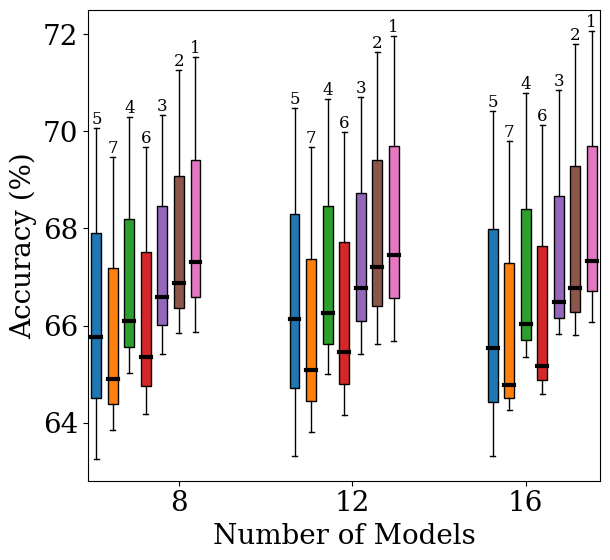

In [15]:
cinic_fl_borda = {k: [cinic_fl_8[k]['borda'], cinic_fl_12[k]['borda'], cinic_fl_16[k]['borda']] for k in cinic_fl_8.keys()}
key_mapping = {
    "loo": "LOO weighted",
    "unweighted": "Unweighted",
    "accuracy": "Acc weighted",
    "crh": "CRH weighted",
    "entropy": "Inv. Entropy weighted",
    "shapley": "Shap weighted",
    "regression": "Regression"
}

# Create a new dictionary with the desired order
cinic_fl_borda = {key_mapping[key]: cinic_fl_borda[key] for key in key_mapping}
markers = [".-",",-","o-","v-","^-","<-",">-","1-","2-","3-","4-","s-","p","P","*","h","H","+","x","X","D","d","|","_"]
# Store medians for different number of teachers for all methods
cinic_fl_borda_meds = []
for method in cinic_fl_borda.keys():
    # if "LOO" not in method:
    cinic_fl_borda_meds.append(np.median(cinic_fl_borda[method], axis=0))
cinic_fl_borda_meds = np.array(cinic_fl_borda_meds)

cinic_fl_borda_ranks = []

for i in range(cinic_fl_borda_meds.shape[1]):
    cinic_fl_borda_ranks.append(len(cinic_fl_borda_meds[:,i]) - cinic_fl_borda_meds[:,i].argsort().argsort())

boxes = [(i,j) for i in range(3) for j in range(7)]
cinic_fl_borda_ranks_dict = {(i,j):cinic_fl_borda_ranks[i][j] for i in range(3) for j in range(7)}
cinic_fl_borda.keys()

plt.figure(figsize=(6.5, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
artists = []

teachers = [8,12,16]
num_teachers = len(teachers)
techniques = list(cinic_fl_borda.keys())
num_techniques = len(techniques)

# Dictionary to store median values for each box
medians_dict = {}
rank_pos_dict = {}
for teacher_index in range(num_teachers):
    x_positions = np.arange(num_techniques) + 1.5*teacher_index * (num_techniques + 1)
    for technique_index, technique in enumerate(techniques):
        arr = np.array(cinic_fl_borda[technique])
        bp = plt.boxplot(arr[:, teacher_index], medianprops=dict(color="black", linewidth=3), positions=[x_positions[technique_index]], widths=0.6, patch_artist=True, showfliers=False)
        [box.set_facecolor(colors[technique_index]) for box in bp['boxes']]
        artists.append(bp['boxes'][0])

        # Calculate median value for each box and store it in the dictionary
        median_val = bp['whiskers'][1].get_ydata()[0] #np.median(100 * arr[:, teacher_index])
        medians_dict[(teacher_index, technique_index)] = median_val
        rank_pos_dict[(teacher_index, technique_index)] = bp['whiskers'][1].get_ydata()[1]

# Annotate boxes with ranks
for teacher_index in range(num_teachers):
    for technique_index, technique in enumerate(techniques):
        box = (teacher_index, technique_index)
        rank = cinic_fl_borda_ranks_dict[box]
        median_val = medians_dict[box]
        rank_pos = rank_pos_dict[box]
        plt.text(1.5*teacher_index * (num_techniques + 1) + technique_index, rank_pos, rank, ha='center', va='bottom', size = 12)

plt.xticks(np.arange(num_teachers) * (num_techniques+3.5) + num_techniques-2, [f'{teachers[i]}' for i in range(num_teachers)])
# plt.legend(artists, techniques, loc='lower left')
plt.ylabel('Accuracy (%)')
plt.xlabel('Number of Models')
plt.tight_layout()
plt.ylim(top = 72.5)
plt.savefig('cinic_fl_borda.pdf')
plt.show()

### CINIC FL Plurality

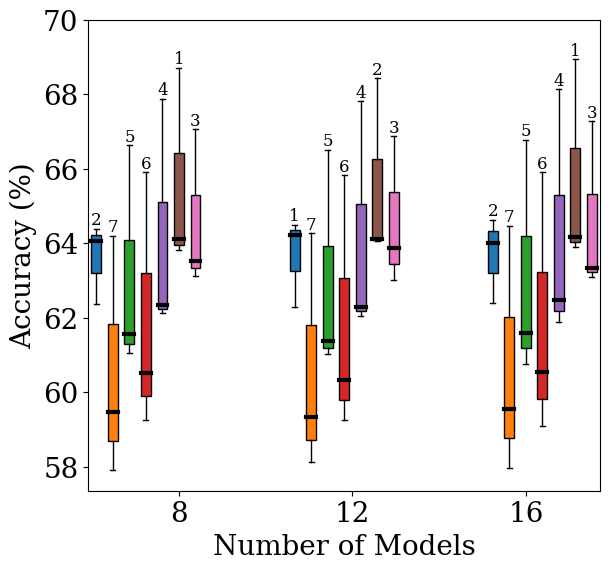

In [16]:
cinic_fl_plurality = {k: [cinic_fl_8[k]['plurality'], cinic_fl_12[k]['plurality'], cinic_fl_16[k]['plurality']] for k in cinic_fl_8.keys()}
key_mapping = {
    "loo": "LOO weighted",
    "unweighted": "Unweighted",
    "accuracy": "Acc weighted",
    "crh": "CRH weighted",
    "entropy": "Inv. Entropy weighted",
    "shapley": "Shap weighted",
    "regression": "Regression"
}

# Create a new dictionary with the desired order
cinic_fl_plurality = {key_mapping[key]: cinic_fl_plurality[key] for key in key_mapping}
markers = [".-",",-","o-","v-","^-","<-",">-","1-","2-","3-","4-","s-","p","P","*","h","H","+","x","X","D","d","|","_"]
# Store medians for different number of teachers for all methods
cinic_fl_plurality_meds = []
for method in cinic_fl_plurality.keys():
    # if "LOO" not in method:
    cinic_fl_plurality_meds.append(np.median(cinic_fl_plurality[method], axis=0))
cinic_fl_plurality_meds = np.array(cinic_fl_plurality_meds)

cinic_fl_plurality_ranks = []

for i in range(cinic_fl_plurality_meds.shape[1]):
    cinic_fl_plurality_ranks.append(len(cinic_fl_plurality_meds[:,i]) - cinic_fl_plurality_meds[:,i].argsort().argsort())

boxes = [(i,j) for i in range(3) for j in range(7)]
cinic_fl_plurality_ranks_dict = {(i,j):cinic_fl_plurality_ranks[i][j] for i in range(3) for j in range(7)}
cinic_fl_plurality.keys()

plt.figure(figsize=(6.5, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
artists = []

teachers = [8,12,16]
num_teachers = len(teachers)
techniques = list(cinic_fl_plurality.keys())
num_techniques = len(techniques)

# Dictionary to store median values for each box
medians_dict = {}
rank_pos_dict = {}
for teacher_index in range(num_teachers):
    x_positions = np.arange(num_techniques) + 1.5*teacher_index * (num_techniques + 1)
    for technique_index, technique in enumerate(techniques):
        arr = np.array(cinic_fl_plurality[technique])
        bp = plt.boxplot(arr[:, teacher_index], medianprops=dict(color="black", linewidth=3), positions=[x_positions[technique_index]], widths=0.6, patch_artist=True, showfliers=False)
        [box.set_facecolor(colors[technique_index]) for box in bp['boxes']]
        artists.append(bp['boxes'][0])

        # Calculate median value for each box and store it in the dictionary
        median_val = bp['whiskers'][1].get_ydata()[0] #np.median(100 * arr[:, teacher_index])
        medians_dict[(teacher_index, technique_index)] = median_val
        rank_pos_dict[(teacher_index, technique_index)] = bp['whiskers'][1].get_ydata()[1]

# Annotate boxes with ranks
for teacher_index in range(num_teachers):
    for technique_index, technique in enumerate(techniques):
        box = (teacher_index, technique_index)
        rank = cinic_fl_plurality_ranks_dict[box]
        median_val = medians_dict[box]
        rank_pos = rank_pos_dict[box]
        plt.text(1.5*teacher_index * (num_techniques + 1) + technique_index, rank_pos, rank, ha='center', va='bottom', size = 12)

plt.xticks(np.arange(num_teachers) * (num_techniques+3.5) + num_techniques-2, [f'{teachers[i]}' for i in range(num_teachers)])
# plt.legend(artists, techniques, loc='lower left')
plt.ylabel('Accuracy (%)')
plt.xlabel('Number of Models')
plt.tight_layout()
plt.ylim(top = 70)
plt.savefig('cinic_fl_plurality.pdf')
plt.show()

In [17]:
names = []
for key in phising_borda.keys():
    names.append(key.replace(' Borda', ''))

In [18]:
names

['LOO weighted',
 'Unweighted',
 'Acc weighted',
 'CRH weighted',
 'Inv. Entropy weighted',
 'Shap weighted',
 'Regression']

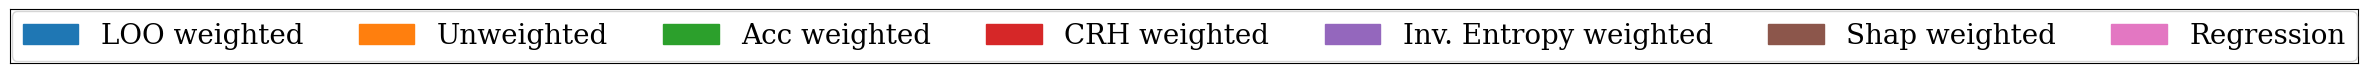

In [19]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
# legend_elements = [Line2D([0], [0], color=colors[i], lw=4, label=names[i]) for i in range(len(names))]
legend_elements = [Patch(facecolor=colors[i], edgecolor=colors[i], label=names[i]) for i in range(0,len(names))]
fig, ax = plt.subplots(figsize=(30.3, 0.7))
ax.tick_params(left = False, right = False , labelleft = False , 
                labelbottom = False, bottom = False) 
ax.legend(handles=legend_elements, loc='center', ncol=7)
plt.savefig('legend.pdf')

In [20]:
# times = pickle.load(open('times-mean.pkl', 'rb'))

In [21]:
# times['Accuracy weight'] = times.pop('accuracy')
# times['CRH weight'] = times.pop('crh')
# times['Inv. Entropy weight'] = times.pop('entropy')
# times['Shapley weight'] = times.pop('shapley')
# times['Regression weight'] = times.pop('regression')
# times['LOO weight'] = times.pop('loo')

In [22]:
# markers2 = [".-",",-","o-","v-","^-",">-","<-","1-","2-","3-","4-","s-","p","P","*","h","H","+","x","X","D","d","|","_"]

In [23]:
# list(times.keys())

In [24]:
# i = 0
# plt.figure(figsize=(12, 8))
# for i in range(len(times.keys())):
#     # if 'Shapley' not in list(times.keys())[i] and "LOO" not in list(times.keys())[i]:
#     plt.plot(range(3,17), times[list(times.keys())[i]], markers[2:][i], color = colors[2:][i], label=list(times.keys())[i])
#     i+=1
# plt.yscale('log')
# plt.ylabel("Log (Time in seconds)")
# plt.xlabel("Number of models")
# plt.legend()
# plt.savefig('times.pdf')

In [25]:
# new_names = [key for key in times.keys()]

In [26]:
# new_names

In [27]:
# from matplotlib.lines import Line2D
# from matplotlib.patches import Patch

# colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
# # legend_elements = [Line2D([0], [0], color=colors[i], lw=4, label=names[i]) for i in range(len(names))]
# legend_elements = [Patch(facecolor=colors[2:][i], edgecolor=colors[2:][i], label=new_names[i]) for i in range(0,len(new_names))]
# fig, ax = plt.subplots(figsize=(27, 0.7))
# ax.tick_params(left = False, right = False , labelleft = False , 
#                 labelbottom = False, bottom = False) 
# ax.legend(handles=legend_elements, loc='center', ncol=6)
# plt.savefig('legend_time.pdf')

### Significance test

In [28]:
colors_significance = [colors[0]]
colors_significance.extend(colors[2:])

In [29]:
import numpy as np
from scipy.stats import ttest_ind

#### Phising data

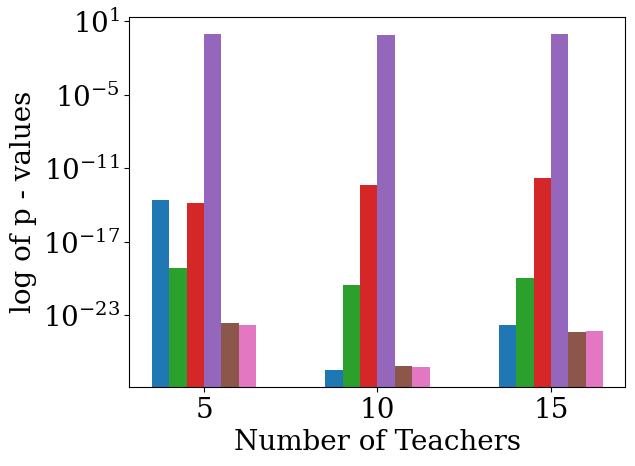

In [56]:
phising_borda_p_values = {}
for key in phising_borda.keys():
    if key != 'Unweighted':
        phising_borda_p_values[key] = []
        for i in range(3):
            v1 = phising_borda[key][i]
            v2 = phising_borda['Unweighted'][i]
            res = ttest_ind(v1, v2)
            phising_borda_p_values[key].append(res.pvalue)

phising_borda_df = pd.DataFrame(phising_borda_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
phising_borda_df_transposed = phising_borda_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(phising_borda_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(phising_borda_df_transposed.index):
    ax.bar(index + i * bar_width, phising_borda_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(phising_borda_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['5', '10', '15'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('ttest/phising_borda_p_values.pdf')

# Display the plot
plt.show()

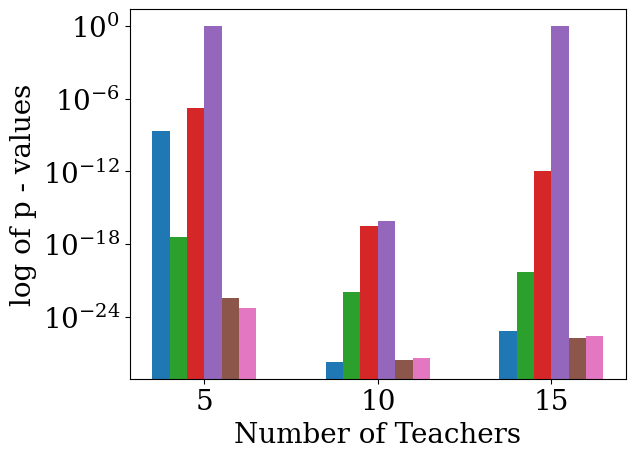

In [57]:
phising_plurality_p_values = {}
for key in phising_plurality.keys():
    if key != 'Unweighted':
        phising_plurality_p_values[key] = []
        for i in range(3):
            v1 = phising_plurality[key][i]
            v2 = phising_plurality['Unweighted'][i]
            res = ttest_ind(v1, v2)
            phising_plurality_p_values[key].append(res.pvalue)

phising_plurality_df = pd.DataFrame(phising_plurality_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
phising_plurality_df_transposed = phising_plurality_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(phising_plurality_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(phising_plurality_df_transposed.index):
    ax.bar(index + i * bar_width, phising_plurality_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(phising_plurality_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['5', '10', '15'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('ttest/phising_plurality_p_values.pdf')

# Display the plot
plt.show()

### DMOZ

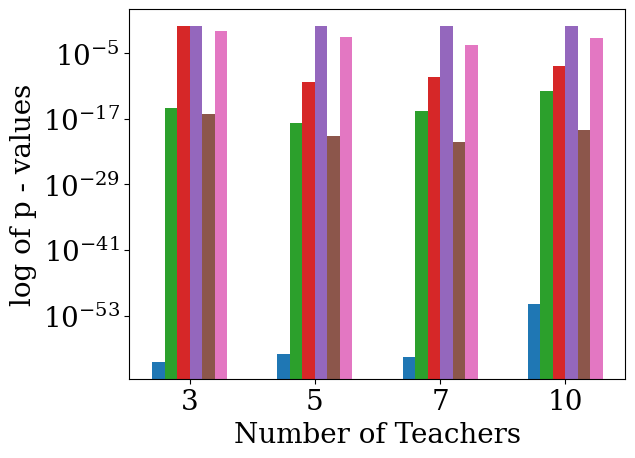

In [58]:
dmoz_borda_p_values = {}
for key in dmoz_borda.keys():
    if key != 'Unweighted':
        dmoz_borda_p_values[key] = []
        for i in range(4):
            v1 = dmoz_borda[key][i]
            v2 = dmoz_borda['Unweighted'][i]
            res = ttest_ind(v1, v2)
            dmoz_borda_p_values[key].append(res.pvalue)

dmoz_borda_df = pd.DataFrame(dmoz_borda_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
dmoz_borda_df_transposed = dmoz_borda_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(dmoz_borda_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(dmoz_borda_df_transposed.index):
    ax.bar(index + i * bar_width, dmoz_borda_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(dmoz_borda_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['3', '5', '7', '10'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('ttest/dmoz_borda_p_values.pdf')

# Display the plot
plt.show()

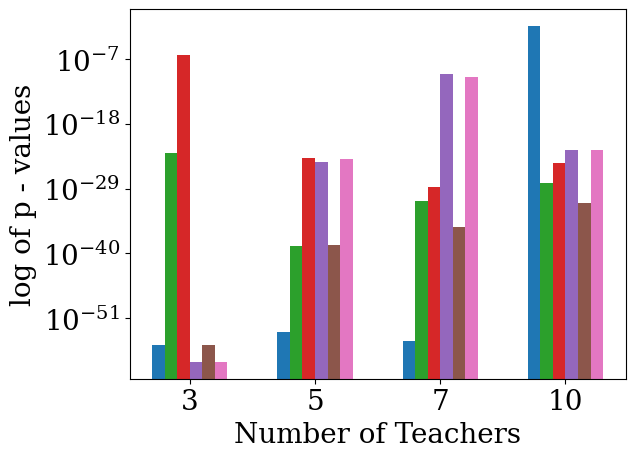

In [59]:
dmoz_plurality_p_values = {}
for key in dmoz_plurality.keys():
    if key != 'Unweighted':
        dmoz_plurality_p_values[key] = []
        for i in range(4):
            v1 = dmoz_plurality[key][i]
            v2 = dmoz_plurality['Unweighted'][i]
            res = ttest_ind(v1, v2)
            dmoz_plurality_p_values[key].append(res.pvalue)

dmoz_plurality_df = pd.DataFrame(dmoz_plurality_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
dmoz_plurality_df_transposed = dmoz_plurality_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(dmoz_plurality_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(dmoz_plurality_df_transposed.index):
    ax.bar(index + i * bar_width, dmoz_plurality_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(dmoz_plurality_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['3', '5', '7', '10'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('ttest/dmoz_plurality_p_values.pdf')

# Display the plot
plt.show()

#### CINIC Data

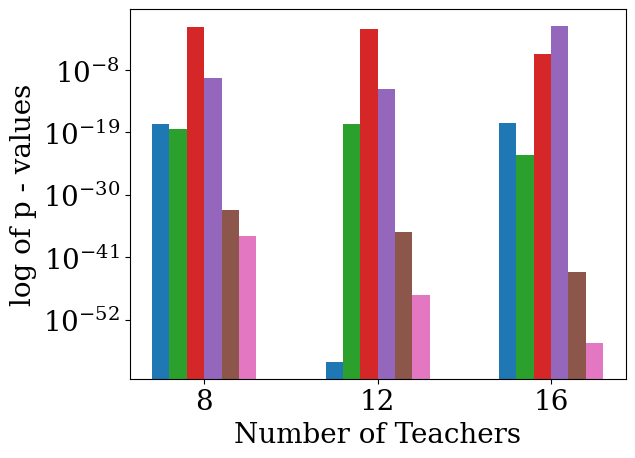

In [60]:
cinic_di_borda_p_values = {}
for key in cinic_di_borda.keys():
    if key != 'Unweighted':
        cinic_di_borda_p_values[key] = []
        for i in range(3):
            v1 = cinic_di_borda[key][i]
            v2 = cinic_di_borda['Unweighted'][i]
            res = ttest_ind(v1, v2)
            cinic_di_borda_p_values[key].append(res.pvalue)

cinic_di_borda_df = pd.DataFrame(cinic_di_borda_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
cinic_di_borda_df_transposed = cinic_di_borda_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(cinic_di_borda_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(cinic_di_borda_df_transposed.index):
    ax.bar(index + i * bar_width, cinic_di_borda_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(cinic_di_borda_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['8', '12', '16'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('ttest/cinic_di_borda_p_values.pdf')

# Display the plot
plt.show()

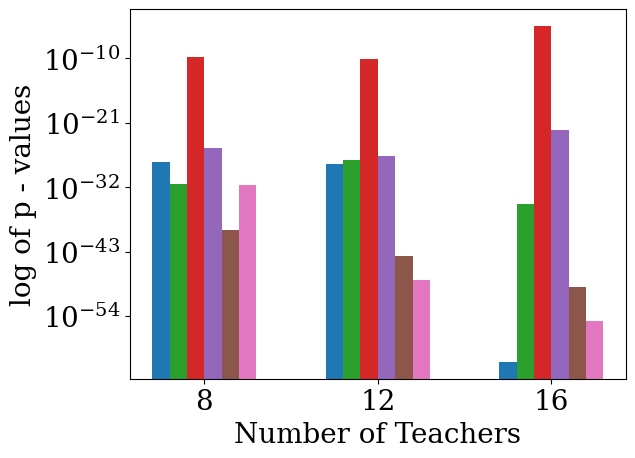

In [61]:
cinic_di_plurality_p_values = {}
for key in cinic_di_plurality.keys():
    if key != 'Unweighted':
        cinic_di_plurality_p_values[key] = []
        for i in range(3):
            v1 = cinic_di_plurality[key][i]
            v2 = cinic_di_plurality['Unweighted'][i]
            res = ttest_ind(v1, v2)
            cinic_di_plurality_p_values[key].append(res.pvalue)

cinic_di_plurality_df = pd.DataFrame(cinic_di_plurality_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
cinic_di_plurality_df_transposed = cinic_di_plurality_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(cinic_di_plurality_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(cinic_di_plurality_df_transposed.index):
    ax.bar(index + i * bar_width, cinic_di_plurality_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(cinic_di_plurality_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['8', '12', '16'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('ttest/cinic_di_plurality_p_values.pdf')

# Display the plot
plt.show()

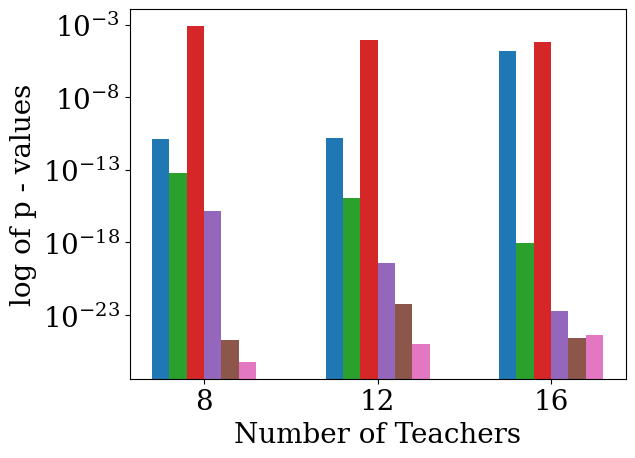

In [62]:
cinic_fl_borda_p_values = {}
for key in cinic_fl_borda.keys():
    if key != 'Unweighted':
        cinic_fl_borda_p_values[key] = []
        for i in range(3):
            v1 = cinic_fl_borda[key][i]
            v2 = cinic_fl_borda['Unweighted'][i]
            res = ttest_ind(v1, v2)
            cinic_fl_borda_p_values[key].append(res.pvalue)

cinic_fl_borda_df = pd.DataFrame(cinic_fl_borda_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
cinic_fl_borda_df_transposed = cinic_fl_borda_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(cinic_fl_borda_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(cinic_fl_borda_df_transposed.index):
    ax.bar(index + i * bar_width, cinic_fl_borda_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(cinic_fl_borda_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['8', '12', '16'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('ttest/cinic_fl_borda_p_values.pdf')

# Display the plot
plt.show()

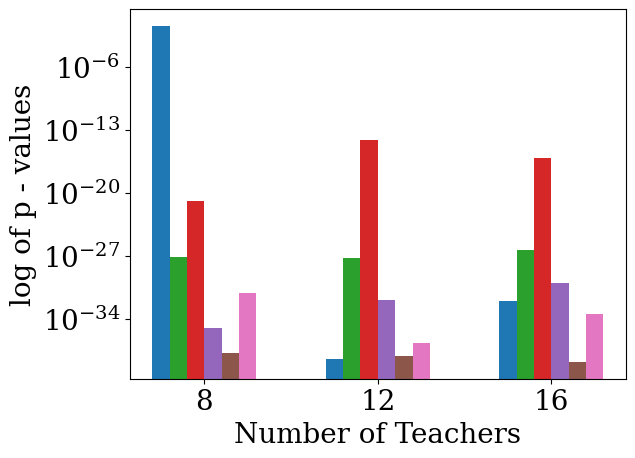

In [63]:
cinic_fl_plurality_p_values = {}
for key in cinic_fl_plurality.keys():
    if key != 'Unweighted':
        cinic_fl_plurality_p_values[key] = []
        for i in range(3):
            v1 = cinic_fl_plurality[key][i]
            v2 = cinic_fl_plurality['Unweighted'][i]
            res = ttest_ind(v1, v2)
            cinic_fl_plurality_p_values[key].append(res.pvalue)

cinic_fl_plurality_df = pd.DataFrame(cinic_fl_plurality_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
cinic_fl_plurality_df_transposed = cinic_fl_plurality_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(cinic_fl_plurality_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(cinic_fl_plurality_df_transposed.index):
    ax.bar(index + i * bar_width, cinic_fl_plurality_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(cinic_fl_plurality_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['8', '12', '16'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('ttest/cinic_fl_plurality_p_values.pdf')

# Display the plot
plt.show()

In [38]:
sig_names = ['LOO weighted',
            'Acc weighted',
            'CRH weighted',
            'Inv. Entropy weighted',
            'Shap weighted',
            'Regression']

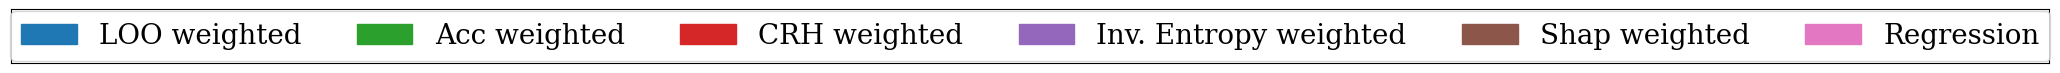

In [39]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

colors = colors_significance
# legend_elements = [Line2D([0], [0], color=colors[i], lw=4, label=names[i]) for i in range(len(names))]
legend_elements = [Patch(facecolor=colors[i], edgecolor=colors[i], label=sig_names[i]) for i in range(0,len(sig_names))]
fig, ax = plt.subplots(figsize=(26.3, 0.7))
ax.tick_params(left = False, right = False , labelleft = False , 
                labelbottom = False, bottom = False) 
ax.legend(handles=legend_elements, loc='center', ncol=7)
plt.savefig('sig_legend.pdf')

# Mann Whitney U Test

In [40]:
from scipy.stats import mannwhitneyu

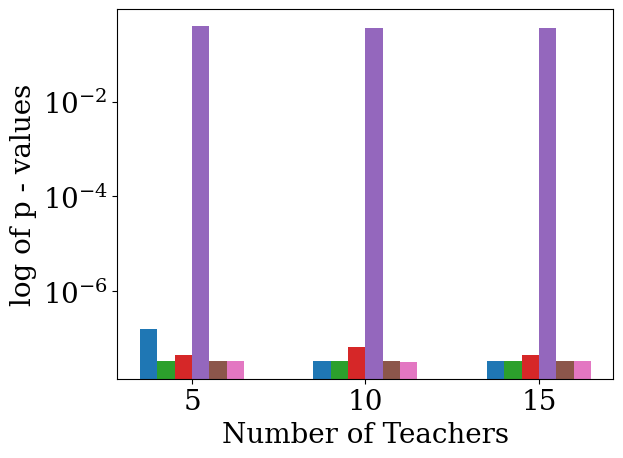

In [41]:
phising_borda_p_values = {}
for key in phising_borda.keys():
    if key != 'Unweighted':
        phising_borda_p_values[key] = []
        for i in range(3):
            v1 = phising_borda[key][i]
            v2 = phising_borda['Unweighted'][i]
            stat, p = mannwhitneyu(v1, v2, alternative='greater')
            phising_borda_p_values[key].append(p)

phising_borda_df = pd.DataFrame(phising_borda_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
phising_borda_df_transposed = phising_borda_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(phising_borda_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(phising_borda_df_transposed.index):
    ax.bar(index + i * bar_width, phising_borda_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(phising_borda_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['5', '10', '15'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('mannwhitney/phising_borda_p_values_mw.pdf')

# Display the plot
plt.show()

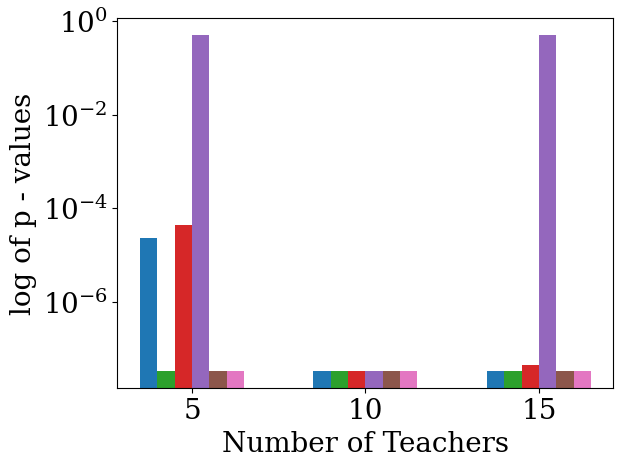

In [42]:
phising_plurality_p_values = {}
for key in phising_plurality.keys():
    if key != 'Unweighted':
        phising_plurality_p_values[key] = []
        for i in range(3):
            v1 = phising_plurality[key][i]
            v2 = phising_plurality['Unweighted'][i]
            stat, p = mannwhitneyu(v1, v2, alternative='greater')
            phising_plurality_p_values[key].append(p)

phising_plurality_df = pd.DataFrame(phising_plurality_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
phising_plurality_df_transposed = phising_plurality_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(phising_plurality_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(phising_plurality_df_transposed.index):
    ax.bar(index + i * bar_width, phising_plurality_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(phising_plurality_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['5', '10', '15'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('mannwhitney/phising_plurality_p_values_mw.pdf')

# Display the plot
plt.show()

### DMOZ

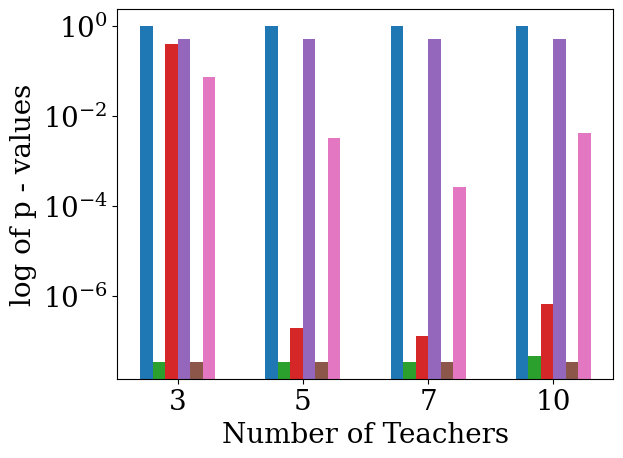

In [43]:
dmoz_borda_p_values = {}
for key in dmoz_borda.keys():
    if key != 'Unweighted':
        dmoz_borda_p_values[key] = []
        for i in range(4):
            v1 = dmoz_borda[key][i]
            v2 = dmoz_borda['Unweighted'][i]
            stat, p = mannwhitneyu(v1, v2, alternative='greater')
            dmoz_borda_p_values[key].append(p)

dmoz_borda_df = pd.DataFrame(dmoz_borda_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
dmoz_borda_df_transposed = dmoz_borda_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(dmoz_borda_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(dmoz_borda_df_transposed.index):
    ax.bar(index + i * bar_width, dmoz_borda_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(dmoz_borda_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['3', '5', '7', '10'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('mannwhitney/dmoz_borda_p_values_mw.pdf')

# Display the plot
plt.show()

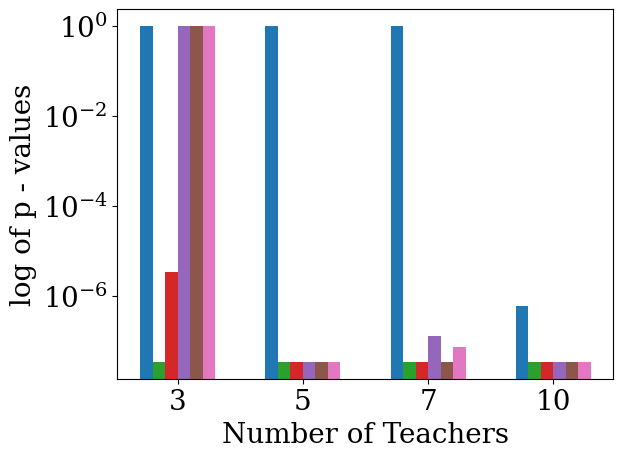

In [44]:
dmoz_plurality_p_values = {}
for key in dmoz_plurality.keys():
    if key != 'Unweighted':
        dmoz_plurality_p_values[key] = []
        for i in range(4):
            v1 = dmoz_plurality[key][i]
            v2 = dmoz_plurality['Unweighted'][i]
            stat, p = mannwhitneyu(v1, v2, alternative='greater')
            dmoz_plurality_p_values[key].append(p)

dmoz_plurality_df = pd.DataFrame(dmoz_plurality_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
dmoz_plurality_df_transposed = dmoz_plurality_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(dmoz_plurality_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(dmoz_plurality_df_transposed.index):
    ax.bar(index + i * bar_width, dmoz_plurality_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(dmoz_plurality_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['3', '5', '7', '10'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('mannwhitney/dmoz_plurality_p_values_mw.pdf')

# Display the plot
plt.show()

#### CINIC Data

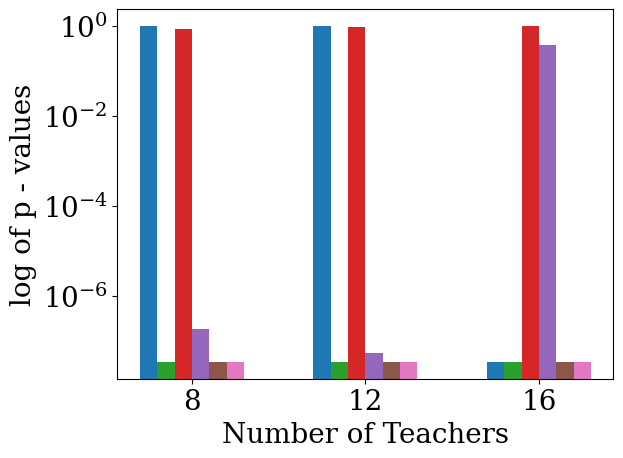

In [45]:
cinic_di_borda_p_values = {}
for key in cinic_di_borda.keys():
    if key != 'Unweighted':
        cinic_di_borda_p_values[key] = []
        for i in range(3):
            v1 = cinic_di_borda[key][i]
            v2 = cinic_di_borda['Unweighted'][i]
            stats, p = mannwhitneyu(v1, v2, alternative='greater')
            cinic_di_borda_p_values[key].append(p)

cinic_di_borda_df = pd.DataFrame(cinic_di_borda_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
cinic_di_borda_df_transposed = cinic_di_borda_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(cinic_di_borda_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(cinic_di_borda_df_transposed.index):
    ax.bar(index + i * bar_width, cinic_di_borda_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(cinic_di_borda_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['8', '12', '16'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('mannwhitney/cinic_di_borda_p_values_mw.pdf')

# Display the plot
plt.show()

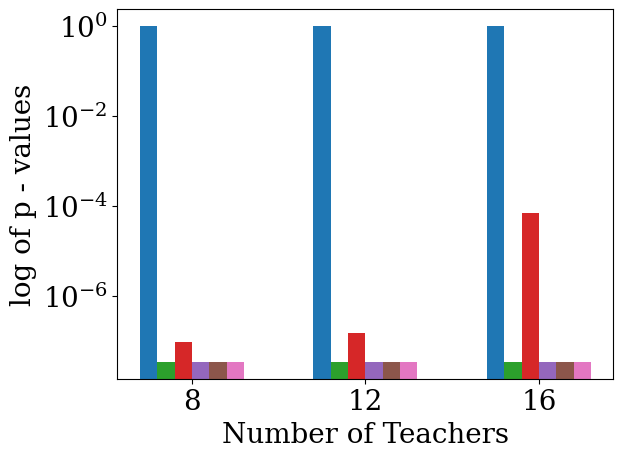

In [46]:
cinic_di_plurality_p_values = {}
for key in cinic_di_plurality.keys():
    if key != 'Unweighted':
        cinic_di_plurality_p_values[key] = []
        for i in range(3):
            v1 = cinic_di_plurality[key][i]
            v2 = cinic_di_plurality['Unweighted'][i]
            stats, p = mannwhitneyu(v1, v2, alternative='greater')
            cinic_di_plurality_p_values[key].append(p)

cinic_di_plurality_df = pd.DataFrame(cinic_di_plurality_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
cinic_di_plurality_df_transposed = cinic_di_plurality_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(cinic_di_plurality_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(cinic_di_plurality_df_transposed.index):
    ax.bar(index + i * bar_width, cinic_di_plurality_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(cinic_di_plurality_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['8', '12', '16'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('mannwhitney/cinic_di_plurality_p_values_mw.pdf')

# Display the plot
plt.show()

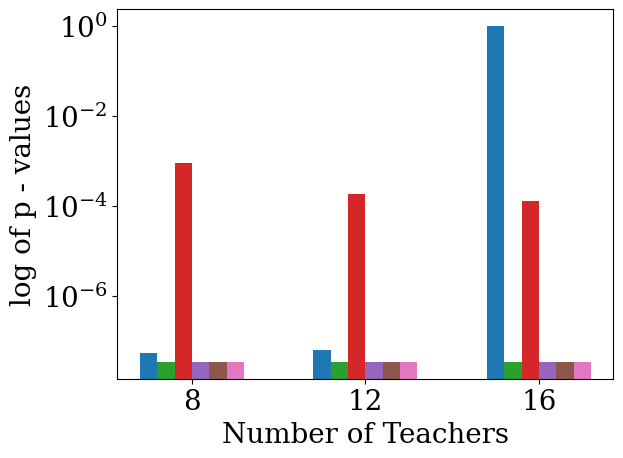

In [47]:
cinic_fl_borda_p_values = {}
for key in cinic_fl_borda.keys():
    if key != 'Unweighted':
        cinic_fl_borda_p_values[key] = []
        for i in range(3):
            v1 = cinic_fl_borda[key][i]
            v2 = cinic_fl_borda['Unweighted'][i]
            stats, p = mannwhitneyu(v1, v2, alternative='greater')
            cinic_fl_borda_p_values[key].append(p)

cinic_fl_borda_df = pd.DataFrame(cinic_fl_borda_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
cinic_fl_borda_df_transposed = cinic_fl_borda_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(cinic_fl_borda_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(cinic_fl_borda_df_transposed.index):
    ax.bar(index + i * bar_width, cinic_fl_borda_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(cinic_fl_borda_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['8', '12', '16'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('mannwhitney/cinic_fl_borda_p_values_wm.pdf')

# Display the plot
plt.show()

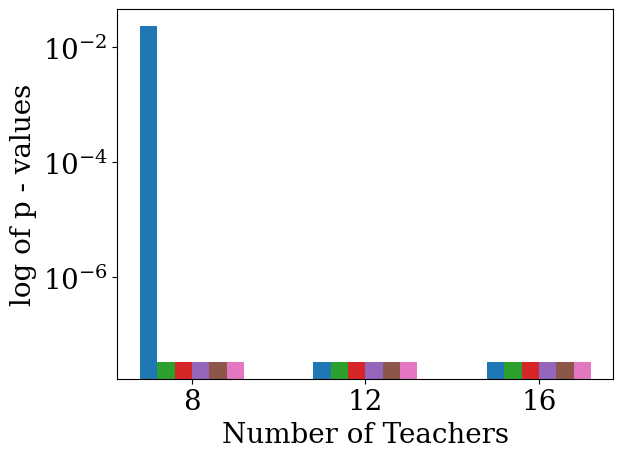

In [48]:
cinic_fl_plurality_p_values = {}
for key in cinic_fl_plurality.keys():
    if key != 'Unweighted':
        cinic_fl_plurality_p_values[key] = []
        for i in range(3):
            v1 = cinic_fl_plurality[key][i]
            v2 = cinic_fl_plurality['Unweighted'][i]
            stats, p = mannwhitneyu(v1, v2, alternative='greater')
            cinic_fl_plurality_p_values[key].append(p)

cinic_fl_plurality_df = pd.DataFrame(cinic_fl_plurality_p_values)

# Transpose the dataframe to switch rows and columns for grouping by number of teachers
cinic_fl_plurality_df_transposed = cinic_fl_plurality_df.T

# Plot settings
bar_width = 0.1
index = np.arange(len(cinic_fl_plurality_df_transposed.columns))

# Create the plot
fig, ax = plt.subplots()
# Plot bars for each method within each group of teacher models
for i, method in enumerate(cinic_fl_plurality_df_transposed.index):
    ax.bar(index + i * bar_width, cinic_fl_plurality_df_transposed.loc[method], bar_width, label=method, color=colors_significance[i])

# Add labels and title
ax.set_xlabel('Number of Teachers')
ax.set_ylabel('log of p - values')

# Set custom x-ticks and labels to represent the number of teachers
ax.set_xticks(index + (len(cinic_fl_plurality_df_transposed.index) - 1) * bar_width / 2)
ax.set_xticklabels(['8', '12', '16'])

ax.set_yscale('log')

# Save the plot as a PDF
plt.savefig('mannwhitney/cinic_fl_plurality_p_values_mw.pdf')

# Display the plot
plt.show()

In [49]:
sig_names = ['LOO weighted',
            'Acc weighted',
            'CRH weighted',
            'Inv. Entropy weighted',
            'Shap weighted',
            'Regression']

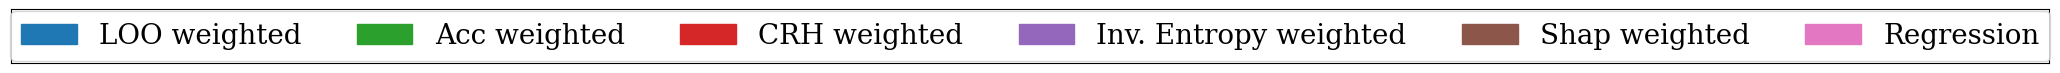

In [50]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

colors = colors_significance
# legend_elements = [Line2D([0], [0], color=colors[i], lw=4, label=names[i]) for i in range(len(names))]
legend_elements = [Patch(facecolor=colors[i], edgecolor=colors[i], label=sig_names[i]) for i in range(0,len(sig_names))]
fig, ax = plt.subplots(figsize=(26.3, 0.7))
ax.tick_params(left = False, right = False , labelleft = False , 
                labelbottom = False, bottom = False) 
ax.legend(handles=legend_elements, loc='center', ncol=7)
plt.savefig('sig_legend.pdf')